## Calculate the MSA mean for PRISM Data (tdmean, tmean, ppt), monthly 2001-2015

In [ ]:

import xarray as xr
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as crs
import cartopy.feature as cfeature
import netCDF4 as nc
import rioxarray as rxr
import numpy as np
import rasterio

In [58]:
import h5py
import numpy as np

TMEAN_FILE = '../data/PRISM Meteorologial Variables/tmean_monthly_01_1980_12_2021.mat'
TDMEAN_FILE = '../data/PRISM Meteorologial Variables/tdmean_monthly_01_1980_12_2021.mat'
PPT_FILE = '../data/PRISM Meteorologial Variables/ppt_monthly_01_1980_12_2021.mat'
def load_h5py_file(file_path: str) -> np.ndarray:
    with h5py.File(file_path, 'r') as f:
        data = f['data'] # have checked that this is the correct key
        raster_data = np.array(data)
    return raster_data # have checked the order is: (time, lon, lat)

# with h5py.File(TMEAN_FILE, 'r') as f:
#     print(list(f.keys()))  # List variables
#     data = f['data']
#     raster_data = np.array(data)
tmean_raster_data = load_h5py_file(TMEAN_FILE)
tdmean_raster_data = load_h5py_file(TDMEAN_FILE)
ppt_raster_data = load_h5py_file(PPT_FILE)

In [6]:
# Calculate transform for .mat data  (boundary, resolution information retrieved from PRISM metadata)
xmin, ymin, xmax, ymax = -125.0208333, 24.0625000, -66.4791667, 49.9375000

# Compute resolution
res_x = 0.04166667  # Longitude resolution
res_y = 0.04166667  # Latitude resolution

prism_transform = rasterio.transform.from_origin(xmin, ymax, res_x, res_y)
print(prism_transform)


In [ ]:
# read shapefile and unit crs
msa_file = '../gis/msa/msaUS_mland_aea1_M1.shp'
msa_gdf_crsaea = gpd.read_file(msa_file)
msa_gdf_crs4269 = msa_gdf_crsaea.to_crs(epsg=4269)

c:\Users\qifanw\Documents\code\.venv\Lib\site-packages\matplotlib\image.py:492: RuntimeWarning: invalid value encountered in subtract
  A_scaled -= a_min


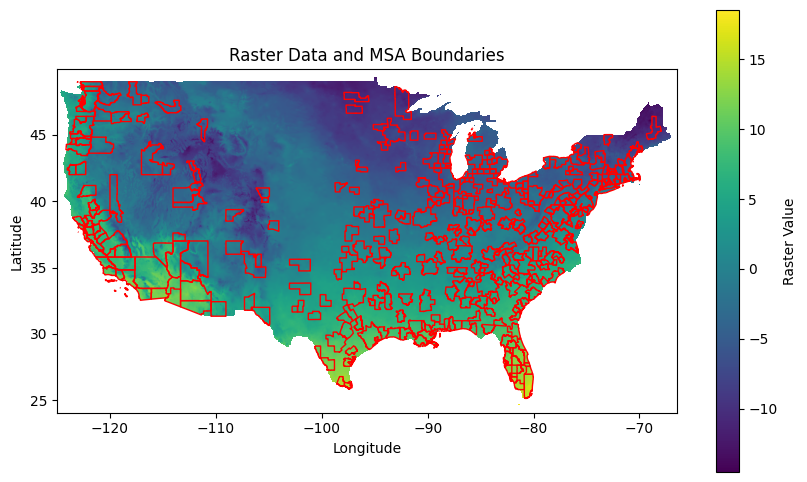

In [ ]:
# Display prism and shapefile on the same map

import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

data_ym = tmean_raster_data[0]  # Get data for January 1980 for test

transform = prism_transform  # Get transformation for plotting
extent = [prism_transform[2], prism_transform[2] + prism_transform[0] * data_ym.shape[1],
        prism_transform[5] + prism_transform[4] * data_ym.shape[0], prism_transform[5]]  # Raster extent

# Plot the raster and MSA shapefile
fig, ax = plt.subplots(figsize=(10, 6))

# Plot raster
im = ax.imshow(data_ym, extent=extent, cmap="viridis", origin="upper")  # Adjust color if needed
plt.colorbar(im, ax=ax, label="Raster Value")  # Add color legend

# Overlay MSA shapefile
msa_gdf_crs4269.boundary.plot(ax=ax, color="red", linewidth=1)  # Plot MSA boundaries

# Customize plot
ax.set_title("Raster Data and MSA Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


In [59]:
from utils import get_masked_raster
import pandas as pd

In [78]:
# get slice of data from 2001-01 to 2015-12
start_year = 2001
end_year = 2015

# msa_name = 'Houston-Pasadena-The Woodlands, TX Metro Area'
# selected_msa = msa_gdf_crs4269[msa_gdf_crs4269['NAMELSAD'] == msa_name]

msa_means = {'tmean': {}, 'tdmean': {}, 'ppt': {}}

from tqdm import tqdm  

# Iterate over each MSA
for idx, msa in tqdm(msa_gdf_crs4269.iterrows(), total=len(msa_gdf_crs4269), desc="Processing MSAs"):
    msa_name = msa['NAMELSAD']
    msa_gdf = msa_gdf_crs4269[msa_gdf_crs4269["NAMELSAD"] == msa_name]  # Extract single MSA as GeoDataFrame
    for cat in ['tmean', 'tdmean', 'ppt']:
        msa_means[cat][msa_name] = {}

    for i in range((start_year - 1980) * 12, (end_year - 1980 + 1) * 12):
        year = i // 12 + 1980
        month = i % 12 + 1
        for cat, raster_data in {'tmean':tmean_raster_data, 'tdmean':tdmean_raster_data, 'ppt':ppt_raster_data}.items():
            data_ym = raster_data[i, :, :]
            data_ym = data_ym.transpose(1, 0) # Transpose to (lat, lon)

            prism_selected_msa = get_masked_raster(msa_gdf, data_ym, prism_transform)
            prism_selected_msa_mean = np.nanmean(prism_selected_msa)

            msa_means[cat][msa_name][f"{year:04d}{month:02d}"] = prism_selected_msa_mean

# msa_df = pd.DataFrame.from_dict(msa_means, orient='index')



Processing MSAs: 100%|██████████| 361/361 [15:32<00:00,  2.58s/it]


In [ ]:
for cat in ['tmean', 'tdmean', 'ppt']:
    cat_msa_mean = pd.DataFrame.from_dict(msa_means['tmean'], orient='index')
    cat_msa_mean.to_csv(f'../data/statistics/prism_msa_mean/{cat}_msa_mean_2001-2015.csv')